In [1]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random

In [56]:
%matplotlib widget

In [2]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [46]:
#gauss
#making lattice
from tqdm.auto import tqdm
def empty_lattice(lc,n1,n2,n3,mid_position=None):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
        lattice=np.round(lattice-mid_position,6)
        return order_pos(lattice),mid_position
    else:
        lattice=np.round(lattice-mid_position,6)
        return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    times=random.randint(1,3)

    #this is too strong
    while num_points<num_atoms*3:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3,mean_position)
        num_points=len(lattice)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-5),axis=1))[0])
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon


def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        # print(i)
        # print(f"prob={threshold},{prob[i]}")
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            # print("pass!")
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return 0.8*(p-np.min(p))/(np.max(p)-np.min(p))
    
# def cross_mutation(lc,parent1,parameters1,parent2,parameters2,mutation_rate=0.1,max_num_atoms=100):
#     n=0
#     parents=[]
#     params=[]
#     while n<2:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.ceil((parameters1[0]*x1+parameters2[0]*x2)))
#         n2_offspring=int(np.ceil(parameters1[1]*x1+parameters2[1]*x2))
#         n3_offspring=int(np.ceil(parameters1[2]*x1+parameters2[2]*x2))
#         atoms_offspring=int(np.ceil(parameters1[3]*x1+parameters2[3]*x2))
#         random_mutation=random.random()
#         if random_mutation<mutation_rate:
#             atoms_offspring=int(np.ceil(atoms_offspring+random_mutation*atoms_offspring))
#         parent,parameter=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         if parameter not in params:
#             parents.append(parent)
#             params.append(parameter)
#             n+=1 
#     return parents,params

# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     if random.random()<cross_over_rate:
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent1,parameter1=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         x1,x2=np.random.dirichlet([1,1])
#         n1_offspring=int(np.round(parameter1[0]*x1+parameter2[0]*x2))
#         n2_offspring=int(np.round(parameter1[1]*x1+parameter2[1]*x2))
#         n3_offspring=int(np.round(parameter1[2]*x1+parameter2[2]*x2))
#         atoms_offspring=int(np.round(parameter1[3]*x1+parameter2[3]*x2))
#         parent2,parameter2=particles_encode_gen_lattice(lc,n1_offspring,n2_offspring,n3_offspring,num_atoms=atoms_offspring,max_num_atoms=max_num_atoms)
#         return parent1,parent2,parameter1,parameter2
#     else:
#         return parent1,parent2,parameter1,parameter2
def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,[0,0,0],lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,[0,0,0],lc,max_num_atoms)
        parent1=parent1_up+parent2_down
        parent2=parent2_up+parent1_down
        parent1[parent1>1]=1
        parent2[parent2>1]=1
        return parent1,parent2
    else:
        return parent1,parent2
# def crossover(lc,parent1,parent2,parameter1,parameter2,cross_over_rate=0.6,max_num_atoms=100):
#     num_atom1=parameter1[3]
#     num_atom2=parameter2[3]
#     min_num=min(num_atom1,num_atom2)

#     if random.random()<cross_over_rate:
#         crossover_point1=random.randint(1,min_num)
#         # crossover_point2=random.randint((len(parent1)-1)//2,len(parent1)-1)
#         # print(parent1)
#         # print(parent2)
#         # swith=random.choice([0,1])
#         return parent1[:crossover_point1]+parent2[crossover_point1:],parent2[:crossover_point1]+parent1[crossover_point1:],parameter1,parameter2
#         # if swith==0:
#         #     return parent1[:crossover_point1]+parent2[crossover_point1:crossover_point2]+parent1[crossover_point2:],parent2[:crossover_point1]+parent1[crossover_point1:crossover_point2]+parent2[crossover_point2:]
#         # if swith==1:
#         #     return parent1[crossover_point1:crossover_point2]+parent2[:crossover_point1]+parent1[crossover_point2:],parent2[crossover_point1:crossover_point2]+parent1[:crossover_point1]+parent2[crossover_point2:]
#     else:
#         return parent1,parent2,parameter1,parameter2
def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    if mr<0.8*mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<6 and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)
    if mr>=0.8*mutation_rate and mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
        particle=np.array(particle)
        dist=np.round(cdist([np.mean(particle,axis=0)],particle),6)
        dist_dict=Counter(dist[0])
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<5 and renum<5:
            atom_index=np.random.randint(1,len(particle)-1)
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # print('no good 2')
            # if renum==0:
            #     # print("no good 2")
            genome_update=atom_trancate_arbi(genome,theta,phi,particle[atom_index][0],particle[atom_index][1],particle[atom_index][2],lc,max_num_atoms)
            renum+=1
            # print(len(np.where(np.array(genome_update)==1)[0]))
        if renum==5:
            genome_update=genome
        return np.array(genome_update)
    else:
        genome_update=genome
        # print(f"size={len(np.where(np.array(genome_update)==1)[0])}")
        return np.array(genome_update)
    

def atom_cut_up_down_center(genome,theta,phi,center,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    # center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>0:
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        else:
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    
    # print(f"1={len(genome_recon)}")
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    print(center)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,x0,y0,z0,lc,max_num_atoms):
    center=[x0,y0,z0]
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,shell,lc,max_num_atoms):
    encodes=genome.copy()
    atom_num=len(np.where(encodes==1)[0])
    CN_steps=[]
    index_particle=[]
    zero_dict=dict()
    control=0
    while control<100:
        CNs1=[]
        dis1=[]
        index_particle=[]
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        for i in  range(len(big_lattice)):
            if encodes[i]==1:
                CN1,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  dis<=np.round(np.sqrt(2)/2*lc,4) and CN1>4: 
                    index_particle.append(i)
                else:
                    encodes[i]=0
        
        for i in range(len(big_lattice)):     
            if encodes[i]==0:
                CN0,dis=getCN_dis_Oneshell(particle,big_lattice[i],shell,thickness=0.1)
                if  CN0!=0 and dis<=np.round(np.sqrt(2)/2*lc,4):
                    zero_dict[i]=CN0
        zero_dict=dict(sorted(zero_dict.items(), key=lambda item: item[1],reverse=True))
        residual=atom_num-len(index_particle)
        for i in range(residual):
            encodes[list(zero_dict.keys())[i]]=1
        # print(f"particle {j}")
        particle,big_lattice=recon_coordfromcodes(encodes,lc,max_num_atoms)
        atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
        _,_,CN_ave=getCN_dis_N(atom,shell)
        control+=1
        CN_steps.append(CN_ave)
        if control>10:
            if CN_steps[-1]-CN_steps[-2]<1e-3:
                break
    return encodes
        

def genetic_algorithm():
    #1. set up parameters
    max_num_atoms=200
    generations=10
    population_size=100
    lc=3.77
    mutation_rate=0.1
    cross_over_rate=0.8
    shell=1
    descriptors={#"surface ratio": 1,
                #  "atom_number": 100
                "CN1":6,
                "CN2":1.5,
                "CN3":2,
                "CN4":5

    }
    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,_=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
       
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        if generation>10:
            error=abs(fitness_record[generation]-fitness_record[generation-1])
            if error<1e-4:
                break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random


In [16]:
best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'CN1': 6, 'CN2': 1.5, 'CN3': 2, 'CN4': 5}


  0%|          | 0/10 [00:00<?, ?it/s]

Generation0:ave Finess=60.61148200000002,best Predict=[4.71 2.21 2.64 1.71]
Generation1:ave Finess=31.738014000000007,best Predict=[4.11 1.63 2.79 1.63]
Generation2:ave Finess=21.270449,best Predict=[4.85 1.62 2.85 1.54]
Generation3:ave Finess=19.14329,best Predict=[4.85 1.62 2.85 1.54]
Generation4:ave Finess=17.675268000000003,best Predict=[5.   2.27 4.19 2.27]
Generation5:ave Finess=16.653299,best Predict=[3.27 2.14 1.82 2.73]
Generation6:ave Finess=15.869085,best Predict=[4.44 1.76 2.64 1.72]
Generation7:ave Finess=15.705348,best Predict=[4.26 1.84 3.11 2.  ]
Generation8:ave Finess=15.214012,best Predict=[4.26 1.84 3.11 2.  ]
Generation9:ave Finess=15.387815000000003,best Predict=[4.77 2.2  3.43 2.13]
best_index=5


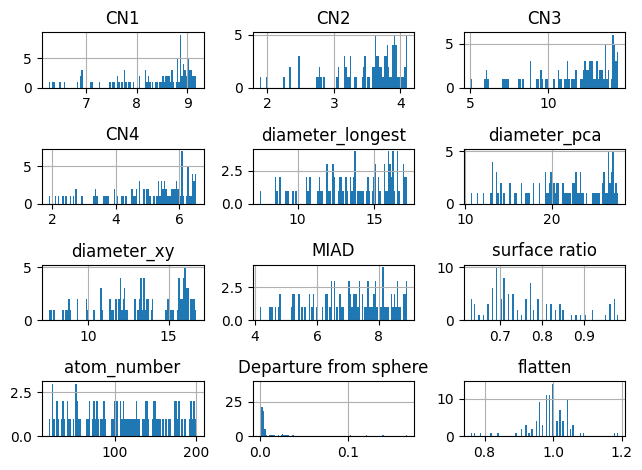

In [7]:
particles_descriptors=[]
bas=[]
for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

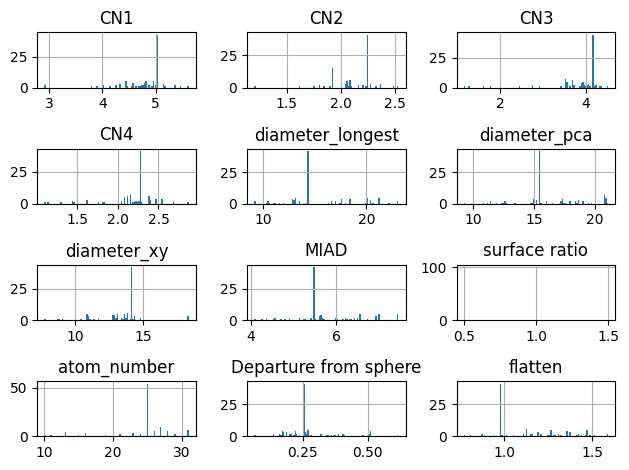

In [8]:
particles_descriptors=[]
bas=[]
for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

# Test

## 1. view particles

In [14]:
view(ini_atom_list[5])

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

## 2. initial condition

In [57]:
def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    
    return genome
def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)



In [61]:
genome=particles_encode_gen_no_oblate(3.77,max_num_atoms=200)
particle,lattice=recon_coordfromcodes(genome,3.77,200)
view(Atoms(positions=particle,symbols=['Pt']*len(particle)))


<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [63]:
mean_position=np.mean(lattice,axis=0)

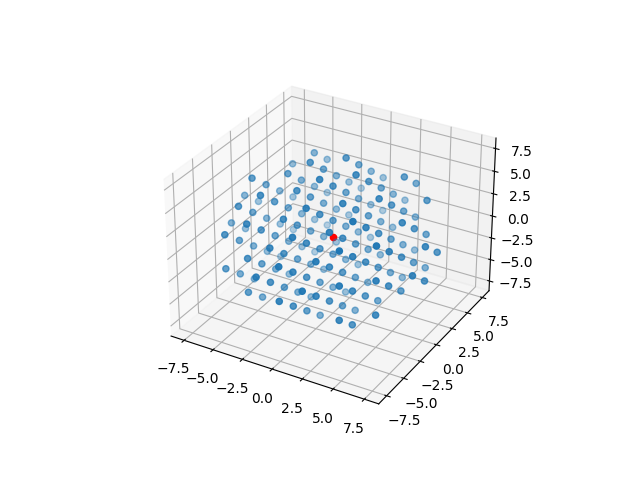

In [64]:
import matplotlib.pyplot as plt
import numpy as np
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(particle[:,0],particle[:,1],particle[:,2])
ax.scatter(mean_position[0],mean_position[1],mean_position[2],c='r')

## 2. truncate function

In [79]:
def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    print(center)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    return genome_recon
def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice,mid_position=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-3),axis=1))[0])
    print(index)
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon

In [80]:
theta=random.uniform(0,np.pi)
phi=random.uniform(0,2*np.pi)
index=1
view(ini_atom_list[index])

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [81]:
genome=encode_fromcoord(ini_atom_list[index].positions,3.77,200)
# genometruncate=atom_trancate_center(genome,theta,phi,3.77,200)
# particle,_=recon_coordfromcodes(genometruncate,3.77,200)
# view(Atoms(positions=particle,symbols=['Pt']*len(particle)))
genome

[]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.